In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import glob
import numpy as np
from matplotlib import colors as mcolors
import colorsys
from sklearn.cluster import KMeans
import plotly.express as px
from scipy.spatial.distance import euclidean
import plotly.graph_objects as go
from scipy.spatial import ConvexHull
from matplotlib.patches import Polygon
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
import seaborn as sns

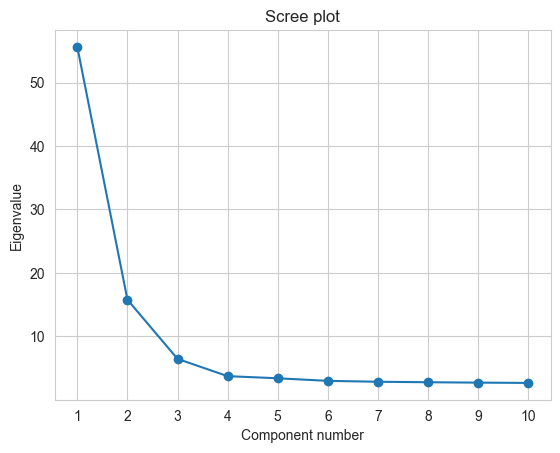

In [5]:
pca_data = pd.read_csv('pca.eigenvec', sep=r'\s+', header=None)
pca_data.columns = ['FID', 'IID'] + [f'PC{i}' for i in range(1, pca_data.shape[1] - 1)]
evals = pd.read_csv('pca.eigenval', header=None)[0]

plt.plot(range(1,11), evals[:10], marker='o')
plt.xticks(range(1, 11))
plt.title('Scree plot')
plt.xlabel('Component number')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.savefig("scree.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [6]:
total_var = evals.sum()
var_explained = (evals / total_var) * 100

print("Variance explained by each PC:")
for i, var in enumerate(var_explained, 1):
    print(f"PC{i}: {var:.1f}%")

Variance explained by each PC:
PC1: 56.3%
PC2: 16.0%
PC3: 6.5%
PC4: 3.8%
PC5: 3.4%
PC6: 3.0%
PC7: 2.9%
PC8: 2.8%
PC9: 2.7%
PC10: 2.7%


In [7]:
print("\nCumulative variance explained:")
cum_var = np.cumsum(var_explained)
for i, var in enumerate(cum_var, 1):
    print(f"PC1 to PC{i}: {var:.1f}%")


Cumulative variance explained:
PC1 to PC1: 56.3%
PC1 to PC2: 72.2%
PC1 to PC3: 78.7%
PC1 to PC4: 82.5%
PC1 to PC5: 85.9%
PC1 to PC6: 88.9%
PC1 to PC7: 91.8%
PC1 to PC8: 94.6%
PC1 to PC9: 97.3%
PC1 to PC10: 100.0%


In [8]:
pop_info = {}

for file in glob.glob('../subsets/*.tsv'):
    df = pd.read_csv(file, sep='\t', header=None)
    for row in df.itertuples(index=False):
        sample = str(row[0]).strip()
        population = str(row[4]).strip()
        pop_info[sample] = population

def get_distinct_colors(n, lightness=0.4, saturation=0.8):
    hues = np.linspace(0, 1, n, endpoint=False)
    return [mcolors.to_hex(colorsys.hls_to_rgb(h, lightness, saturation)) for h in hues]

pca_data['Population'] = pca_data['IID'].map(
    lambda x: pop_info.get(x, 'Kazakh' if str(x).startswith('WE') else 'Unknown')
)

populations = sorted(pca_data['Population'].unique())
color_list = get_distinct_colors(len(populations))
color_dict = dict(zip(populations, color_list))

tot = 0
for pop in populations:
    count = len(pca_data[pca_data['Population'] == pop])
    print(f'{pop}: {count} samples')
    tot += count
print(f'\nTotal samples: {tot}')

supergroup_map = {
    'EUR': ['Toscani', 'Finnish', 'British', 'Iberian'],
    'SAS': ['Punjabi', 'Gujarati', 'Bengali', 'Tamil'],
    'EAS': ['Han Chinese', 'Kinh Vietnamese', 'Dai Chinese', 'Japanese'],
    'Kazakh': ['Kazakh']}

population_to_supergroup = {pop: sg for sg, pops in supergroup_map.items() for pop in pops}
pca_data['Supergroup'] = pca_data['Population'].map(lambda x: population_to_supergroup.get(x, 'Other'))

Bengali: 86 samples
British: 91 samples
Dai Chinese: 93 samples
Finnish: 99 samples
Gujarati: 100 samples
Han Chinese: 100 samples
Iberian: 100 samples
Japanese: 100 samples
Kazakh: 108 samples
Kinh Vietnamese: 99 samples
Punjabi: 96 samples
Tamil: 100 samples
Toscani: 100 samples

Total samples: 1272


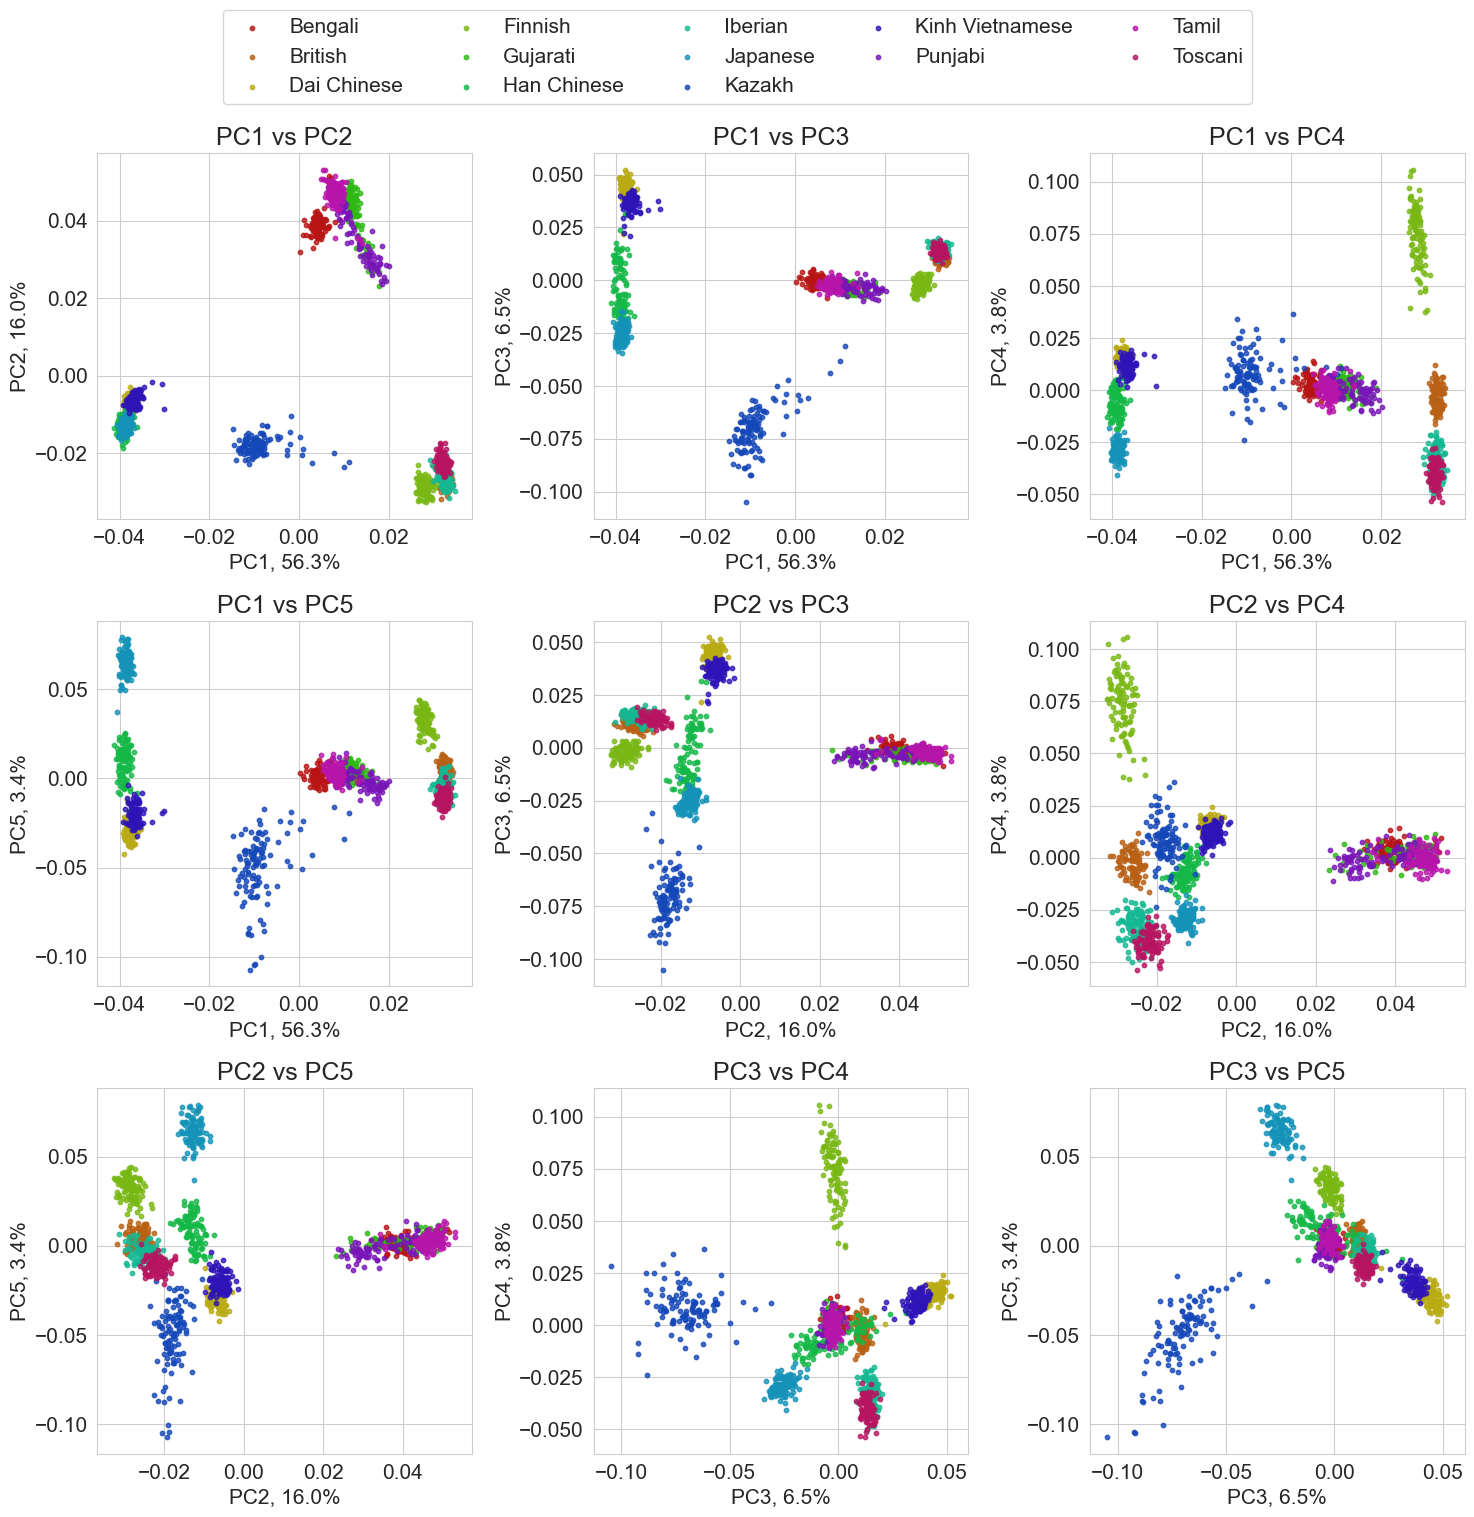

In [9]:
plt.rcParams.update({'font.size': 15})
fig, axs = plt.subplots(3, 3, figsize=(15, 15))
plot_combinations = [(1, 2), (1, 3), (1, 4), (1,5), (2,3), (2,4), (2,5), (3,4), (3,5)]

for ax, (x_pc, y_pc) in zip(axs.flatten(), plot_combinations):
    for pop in sorted(pca_data['Population'].unique()):
        subset = pca_data[pca_data['Population'] == pop]
        supergroup = subset['Supergroup'].iloc[0]
        ax.scatter(
            subset[f'PC{x_pc}'], subset[f'PC{y_pc}'],
            label=pop, color= color_dict[pop], s=10, alpha=0.8)

    ax.set_xlabel(f'PC{x_pc}, {var_explained[(x_pc-1)]:.1f}%')
    ax.set_ylabel(f'PC{y_pc}, {var_explained[(y_pc-1)]:.1f}%')
    ax.set_title(f'PC{x_pc} vs PC{y_pc}')
    ax.grid(True)


handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.95))
plt.savefig("3x3pca.pdf", format="pdf", bbox_inches="tight", dpi=1000)
plt.show()

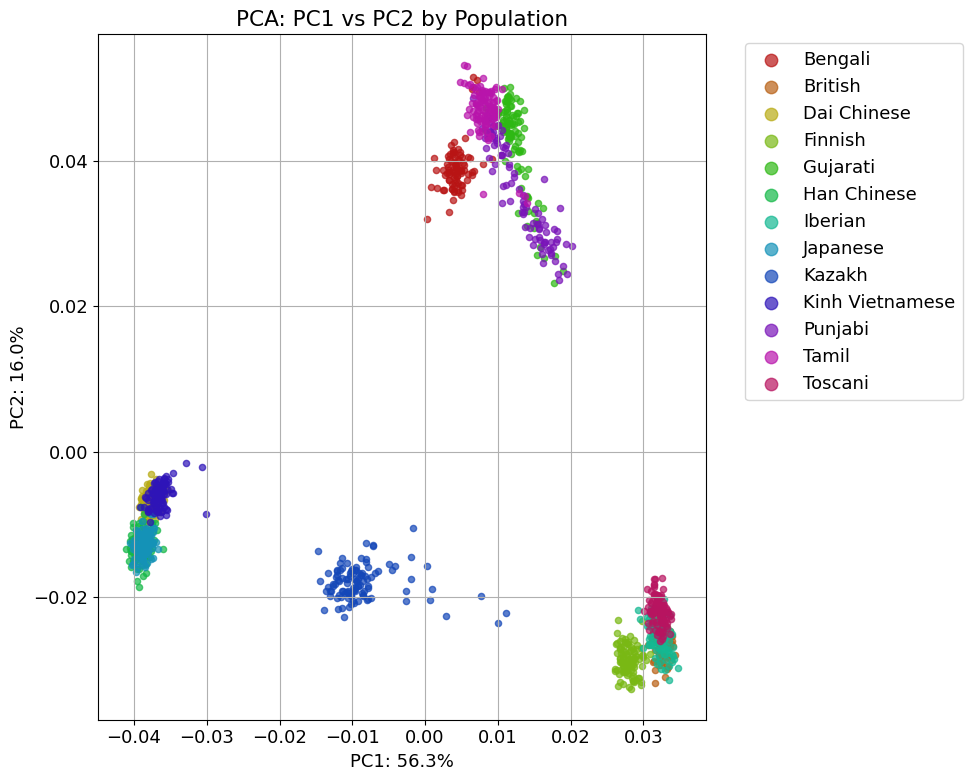

In [29]:
plt.rcParams.update({'font.size': 13})
plt.figure(figsize=(10, 8))
for pop in populations:
    subset = pca_data[pca_data['Population'] == pop]
    plt.scatter(subset['PC1'], subset['PC2'], s=20, color=color_dict[pop], label=pop, alpha=0.7)

plt.xlabel(f'PC1: {var_explained[0]:.1f}%')
plt.ylabel(f'PC2: {var_explained[1]:.1f}%')
plt.title('PCA: PC1 vs PC2 by Population')
plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.savefig("pc1_v_pc2.pdf", format="pdf", bbox_inches="tight", dpi=1000)
plt.show()

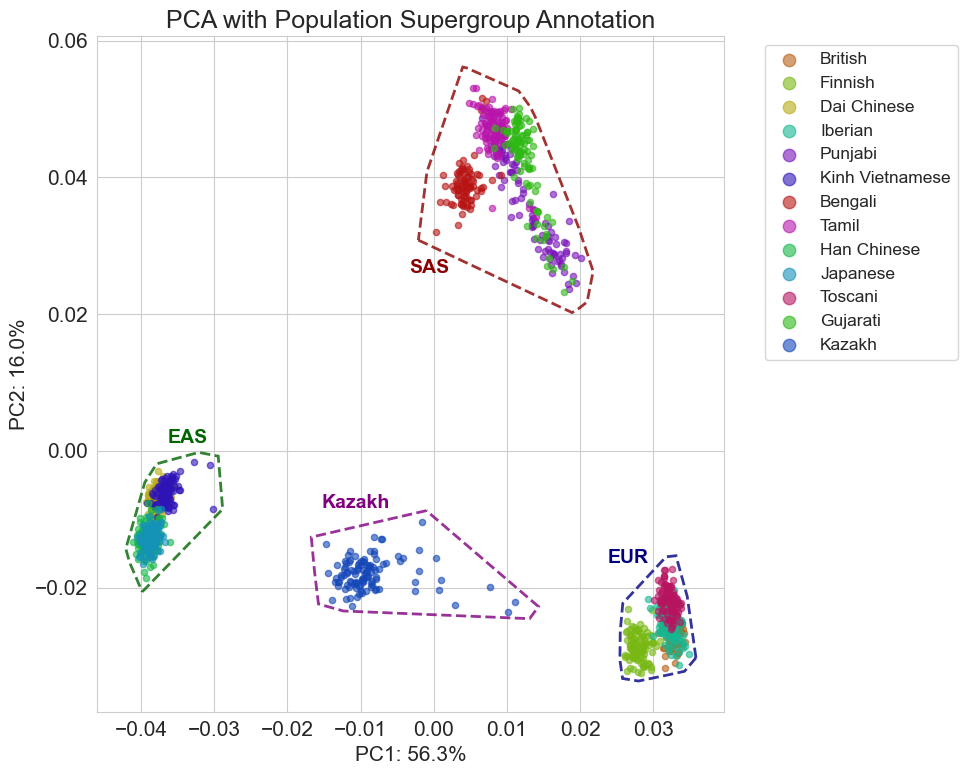

In [10]:
plt.figure(figsize=(10, 8))

for pop in pca_data['Population'].unique():
    sub = pca_data[pca_data['Population'] == pop]
    plt.scatter(sub['PC1'], sub['PC2'],
                color=color_dict[pop], s=20, alpha=0.6, label=pop)

supergroup_colors = {'EUR':'navy','SAS':'darkred','EAS':'darkgreen','Kazakh':'purple'}
label_offsets = {
    'EUR': np.array([ -0.0005,  0.01]),
    'SAS': np.array([ -0.01, -0.01]),
    'EAS': np.array([ 0.0,  0.009]),
    'Kazakh': np.array([-0.001,  0.01]),
}

expansion_factor = 1.2  # 5% larger than the hull

for sg, group_df in pca_data.groupby('Supergroup'):
    if sg == 'Other' or len(group_df) < 3:
        continue

    pts = np.column_stack([group_df['PC1'], group_df['PC2']])
    hull = ConvexHull(pts)
    hull_pts = pts[hull.vertices]

    centroid = hull_pts.mean(axis=0)
    vecs = hull_pts - centroid
    hull_expanded = centroid + vecs * expansion_factor

    outline = Polygon(hull_expanded, closed=True,
                      facecolor='none',
                      edgecolor=supergroup_colors[sg],
                      linewidth=2, linestyle='--', alpha=0.8)
    plt.gca().add_patch(outline)

    offset = label_offsets.get(sg, np.array([0.0, 0.0]))
    x_lbl, y_lbl = centroid + offset
    ha = 'left' if offset[0] >= 0 else 'right'
    va = 'bottom' if offset[1] >= 0 else 'top'
    plt.text(x_lbl, y_lbl, sg,
             fontsize=14, weight='bold',
             color=supergroup_colors[sg],
             ha=ha, va=va)

plt.xlabel(f'PC1: {var_explained[0]:.1f}%')
plt.ylabel(f'PC2: {var_explained[1]:.1f}%')
plt.title('PCA with Population Supergroup Annotation')
plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1),
           loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.savefig("pca_100samp_superpop_outline_transparent.pdf", format="pdf", bbox_inches="tight", dpi = 1000, transparent=True)
plt.show()

In [13]:
for pc in ['PC1', 'PC2', 'PC3']:
    pca_data[pc] = pd.to_numeric(pca_data[pc], errors='coerce')

fig = px.scatter_3d(
    pca_data,
    x='PC1', y='PC2', z='PC3',
    color='Population',
    hover_name='IID',
    title='3D PCA Plot (PC1 vs PC2 vs PC3)',
    opacity=0.8
)

fig.update_traces(marker=dict(size=4))

fig.update_layout(
    width=800,
    height=800,
    title_font=dict(size=24),
    scene=dict(
        xaxis=dict(title=dict(text='PC1', font=dict(size=18)), tickfont=dict(size=14)),
        yaxis=dict(title=dict(text='PC2', font=dict(size=18)), tickfont=dict(size=14)),
        zaxis=dict(title=dict(text='PC3', font=dict(size=18)), tickfont=dict(size=14))
    ),
    legend=dict(font=dict(size=16))
)

fig.update_traces(hoverlabel=dict(font_size=14))
fig.show()
fig.update_layout(
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)"
)
fig.write_image("3d_pca_transparent.pdf", width = 800, height = 800, scale=2)

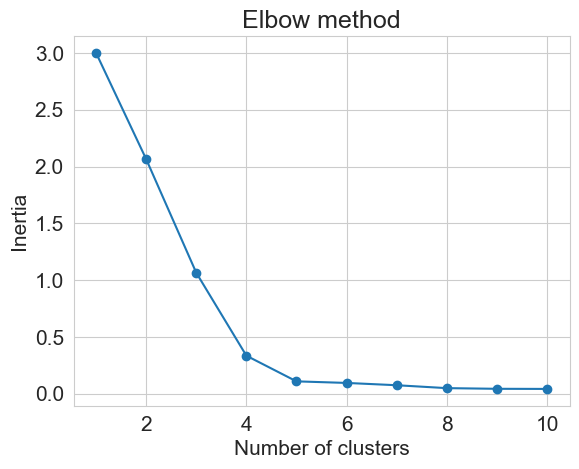

In [15]:
inertias = []
X = pca_data.iloc[:, 2:5].to_numpy(dtype=np.float64)

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.savefig("elbow.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [16]:
pcs = ['PC1', 'PC2', 'PC3']
X = pca_data[pcs]

def silhouette_for_k(x, ks=(2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20), random_state=42):
    scores = {}
    for k in ks:
        km = KMeans(n_clusters=k, n_init='auto', random_state=random_state, algorithm='lloyd')
        labels = km.fit_predict(x)
        scores[k] = silhouette_score(x, labels, metric='euclidean')
    return scores

scores = silhouette_for_k(X, ks=[2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])
best_k = max(scores, key=scores.get)
print("scores:", scores, '\n', "best_k:",  best_k)

scores: {2: 0.42273683949031254, 3: 0.6389660469195052, 4: 0.7671864998612629, 5: 0.8212778836471257, 6: 0.7684536786444122, 7: 0.7552387042094181, 8: 0.6594776643795947, 9: 0.6448405675286192, 10: 0.6176742861696857, 11: 0.5289310681528496, 12: 0.5197242763297893, 13: 0.5256603491630909, 14: 0.4858451393021533, 15: 0.49001320308470697, 16: 0.45967755121432546, 17: 0.4490091853511292, 18: 0.42654671364007973, 19: 0.42450677431614897, 20: 0.4177906263741288} 
 best_k: 5


Kazakh cluster: 3
Kazakh → Cluster 0: 0.0892
Kazakh → Cluster 1: 0.0918
Kazakh → Cluster 2: 0.0618
Kazakh → Cluster 4: 0.1131


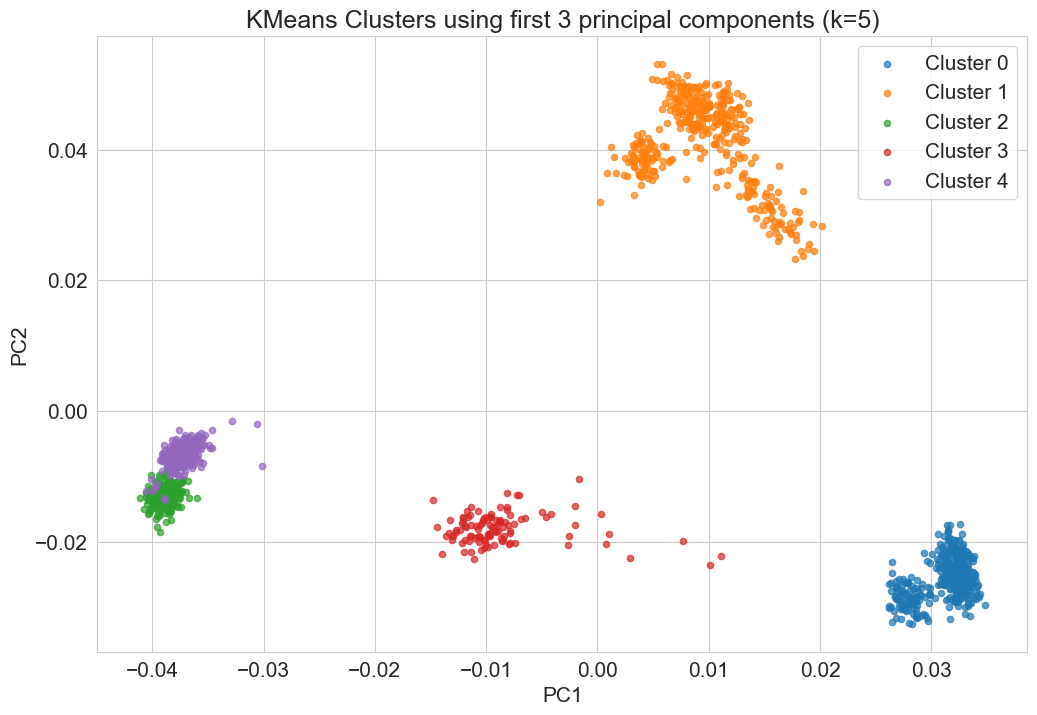

In [17]:
kmeans = KMeans(n_clusters=5, n_init=10, random_state=42)
labels = kmeans.fit_predict(X)
pca_data['Cluster'] = labels

kazakh_counts = (pca_data[pca_data['Population'] == 'Kazakh'].groupby('Cluster').size())
kazakh_cluster = kazakh_counts.idxmax()

centroids = pca_data.groupby('Cluster')[pcs].mean()
kazakh_center = centroids.loc[kazakh_cluster]
distances = {}

for cluster_id in centroids.index:
    if cluster_id == kazakh_cluster:
        continue
    other_center = centroids.loc[cluster_id]
    dist = euclidean(kazakh_center, other_center)
    distances[f"Kazakh → Cluster {cluster_id}"] = dist

print(f"Kazakh cluster: {kazakh_cluster}")
for label, dist in distances.items():
    print(f"{label}: {dist:.4f}")

plt.figure(figsize=(12, 8))
for c in range(5):
    subset = pca_data[pca_data['Cluster'] == c]
    plt.scatter(subset['PC1'], subset['PC2'], s=20, label=f'Cluster {c}', alpha=0.7)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.title('KMeans Clusters using first 3 principal components (k=5)')
plt.savefig("clustering_k5.pdf", format="pdf", bbox_inches="tight", dpi = 1000, transparent=True)
plt.show()


In [13]:
fig = go.Figure()

for cluster_id in centroids.index:
    subset = pca_data[pca_data['Cluster'] == cluster_id]
    fig.add_trace(go.Scatter3d(
        x=subset['PC1'], y=subset['PC2'], z=subset['PC3'],
        mode='markers',
        name=f'Cluster {cluster_id}',
        marker=dict(size=3),
        opacity=0.6))

for cluster_id, row in centroids.iterrows():
    fig.add_trace(go.Scatter3d(
        x=[row['PC1']], y=[row['PC2']], z=[row['PC3']],
        mode='markers+text',
        name=f'Centroid {cluster_id}',
        marker=dict(size=10, color='black' if cluster_id == kazakh_cluster else 'red'),
        text=[f'C{cluster_id}'],
        textposition='top center',
        showlegend=False))

for cluster_id, other_center in centroids.iterrows():
    if cluster_id == kazakh_cluster:
        continue
    fig.add_trace(go.Scatter3d(
        x=[kazakh_center['PC1'], other_center['PC1']],
        y=[kazakh_center['PC2'], other_center['PC2']],
        z=[kazakh_center['PC3'], other_center['PC3']],
        mode='lines',
        name=f'Distance to C{cluster_id}',
        line=dict(color='gray', width=2, dash='dash'),
        showlegend=False))

fig.update_layout(
    width=800,
    height=800,
    title_font=dict(size=24),
    scene=dict(
        xaxis=dict(title=dict(text='PC1', font=dict(size=18)), tickfont=dict(size=14)),
        yaxis=dict(title=dict(text='PC2', font=dict(size=18)), tickfont=dict(size=14)),
        zaxis=dict(title=dict(text='PC3', font=dict(size=18)), tickfont=dict(size=14))
    ),
    legend=dict(font=dict(size=16))
)

fig.update_traces(hoverlabel=dict(font_size=14))
fig.show()
fig.write_image("cluster_plot.pdf",  width=800, height=800, scale=2)

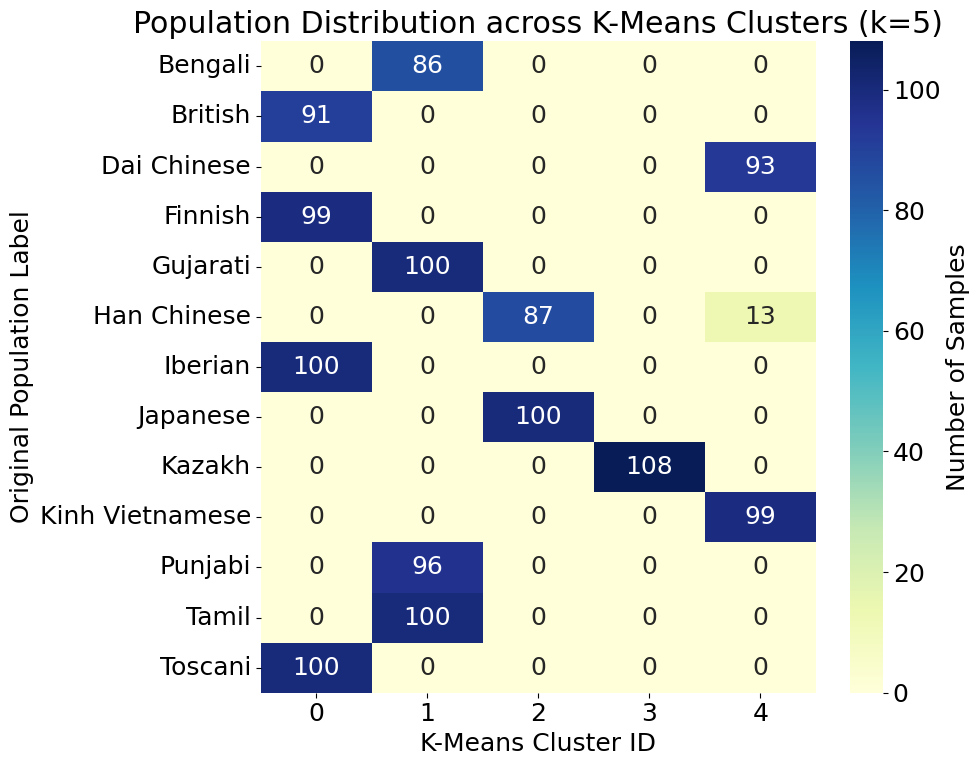

In [38]:
kmeans_contingency = pd.crosstab(pca_data['Population'], pca_data['Cluster'])

plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(10, 8))
sns.heatmap(
    kmeans_contingency,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    cbar_kws={'label': 'Number of Samples'}
)

plt.title('Population Distribution across K-Means Clusters (k=5)')
plt.xlabel('K-Means Cluster ID')
plt.ylabel('Original Population Label')

plt.tight_layout()
plt.savefig("kmeans_population_heatmap.pdf", format="pdf", bbox_inches="tight")
plt.show()

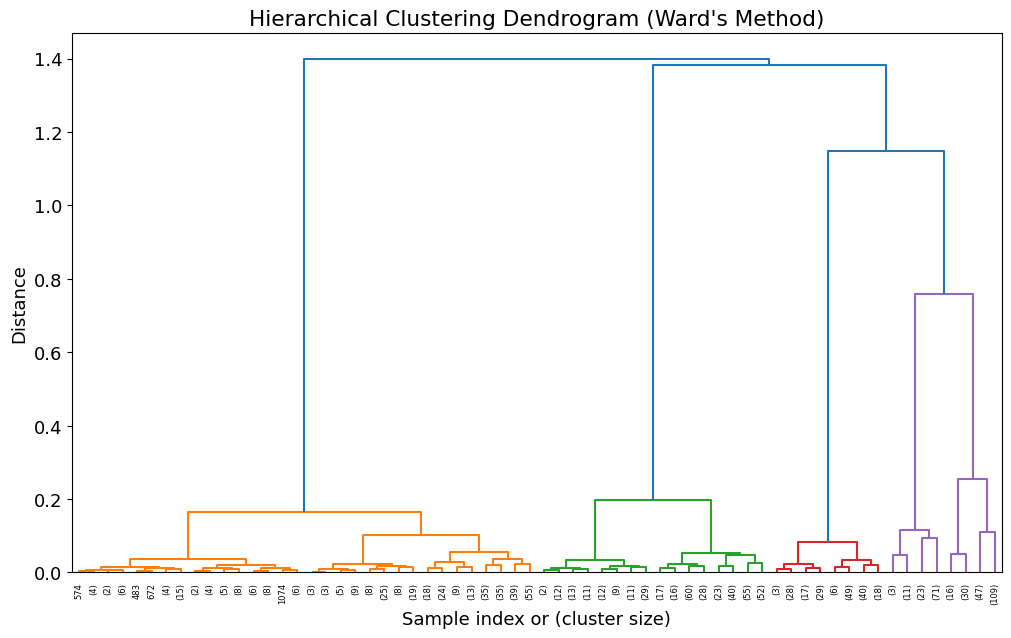

In [16]:
X = pca_data[['PC1', 'PC2', 'PC3']].to_numpy()

Z = linkage(X, method='ward')

plt.figure(figsize=(12, 7))
dendrogram(Z, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram (Ward\'s Method)')
plt.xlabel('Sample index or (cluster size)')
plt.ylabel('Distance')
plt.axhline(y=10, color='r', linestyle='--')
plt.show()

In [42]:
n_clusters = [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
h_scores = []

for i in n_clusters:
    hc = AgglomerativeClustering(n_clusters=i, metric='euclidean', linkage='ward')
    pca_data['HC_Cluster'] = hc.fit_predict(X)

    h_score = silhouette_score(X, pca_data['HC_Cluster'])
    print(f"Hierarchical Clustering Silhouette Score (k={i}): {h_score:.4f}")
    h_scores.append(h_score)

max(h_scores)


Hierarchical Clustering Silhouette Score (k=2): 0.4392
Hierarchical Clustering Silhouette Score (k=3): 0.6623
Hierarchical Clustering Silhouette Score (k=4): 0.7496
Hierarchical Clustering Silhouette Score (k=5): 0.8161
Hierarchical Clustering Silhouette Score (k=6): 0.8074
Hierarchical Clustering Silhouette Score (k=7): 0.7541
Hierarchical Clustering Silhouette Score (k=8): 0.6594
Hierarchical Clustering Silhouette Score (k=9): 0.6392
Hierarchical Clustering Silhouette Score (k=10): 0.6237
Hierarchical Clustering Silhouette Score (k=11): 0.6117
Hierarchical Clustering Silhouette Score (k=12): 0.6060
Hierarchical Clustering Silhouette Score (k=13): 0.5651
Hierarchical Clustering Silhouette Score (k=14): 0.5380
Hierarchical Clustering Silhouette Score (k=15): 0.4449
Hierarchical Clustering Silhouette Score (k=16): 0.4367
Hierarchical Clustering Silhouette Score (k=17): 0.4315
Hierarchical Clustering Silhouette Score (k=18): 0.4157
Hierarchical Clustering Silhouette Score (k=19): 0.4170


0.8161204724248043

In [43]:
h_scores

[0.4391917144341831,
 0.6623398858991972,
 0.7495899261070874,
 0.8161204724248043,
 0.807370097441886,
 0.7540683052203467,
 0.659427754427274,
 0.6392324877603031,
 0.6237146429973047,
 0.61166608895619,
 0.6060172450473321,
 0.5650518368844293,
 0.5380044672032581,
 0.44488109566554573,
 0.4367092653471695,
 0.43152903263690745,
 0.4157036010545668,
 0.41701660098775195,
 0.4256630900985409]

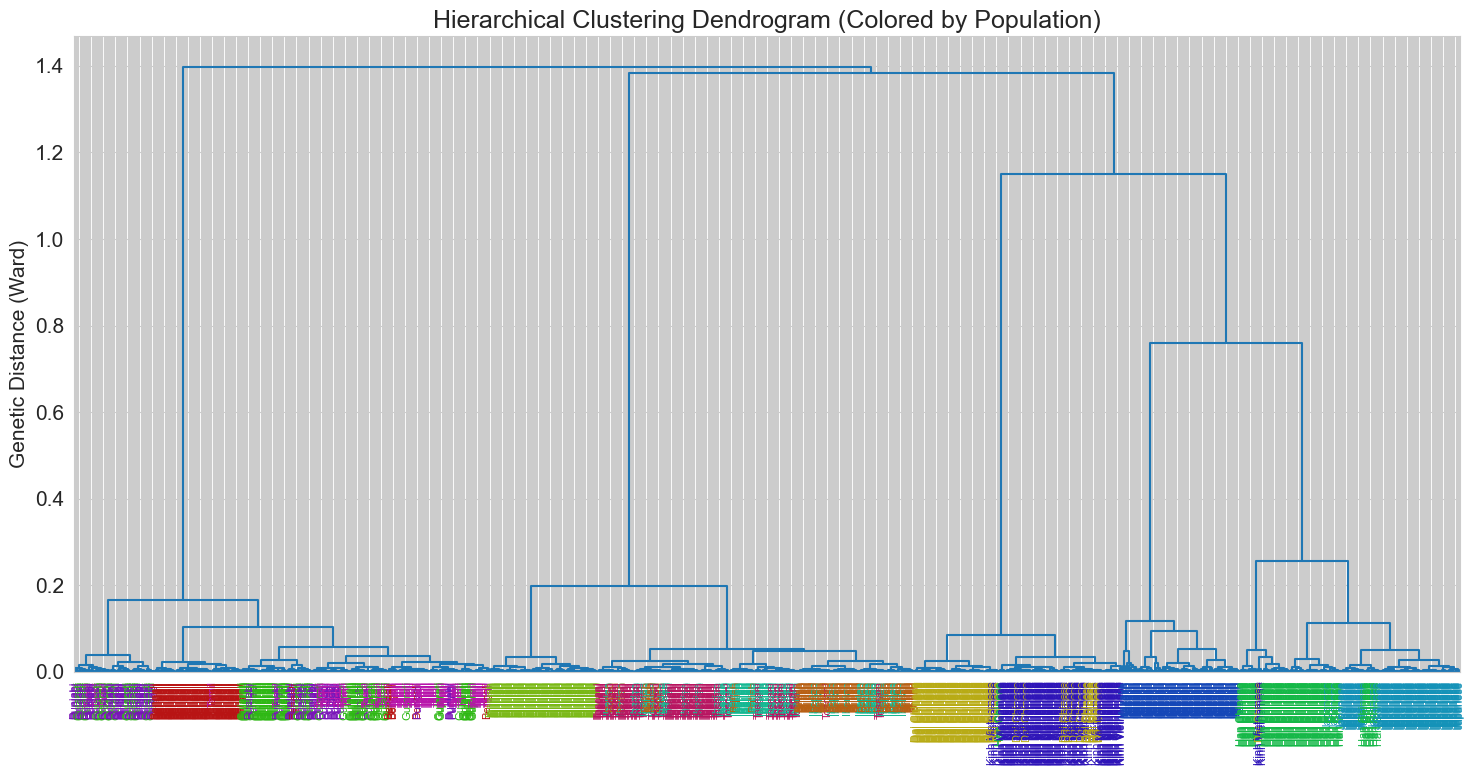

In [18]:
X = pca_data[['PC1', 'PC2', 'PC3']].to_numpy()
Z = linkage(X, method='ward')

pop_labels = pca_data['Population'].tolist()
leaf_colors = [color_dict[p] for p in pop_labels]

plt.figure(figsize=(15, 8))
plt.title('Hierarchical Clustering Dendrogram (Colored by Population)')

ddata = dendrogram(
    Z,
    labels=pop_labels,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=0
)

ax = plt.gca()
xlbls = ax.get_xmajorticklabels()
for i, lbl in enumerate(xlbls):
    val = lbl.get_text()
    lbl.set_color(color_dict[val])

plt.ylabel('Genetic Distance (Ward)')
plt.tight_layout()
plt.savefig("dendrogram_population_transparent.pdf", format="pdf", transparent=True, bbox_inches="tight")
plt.show()

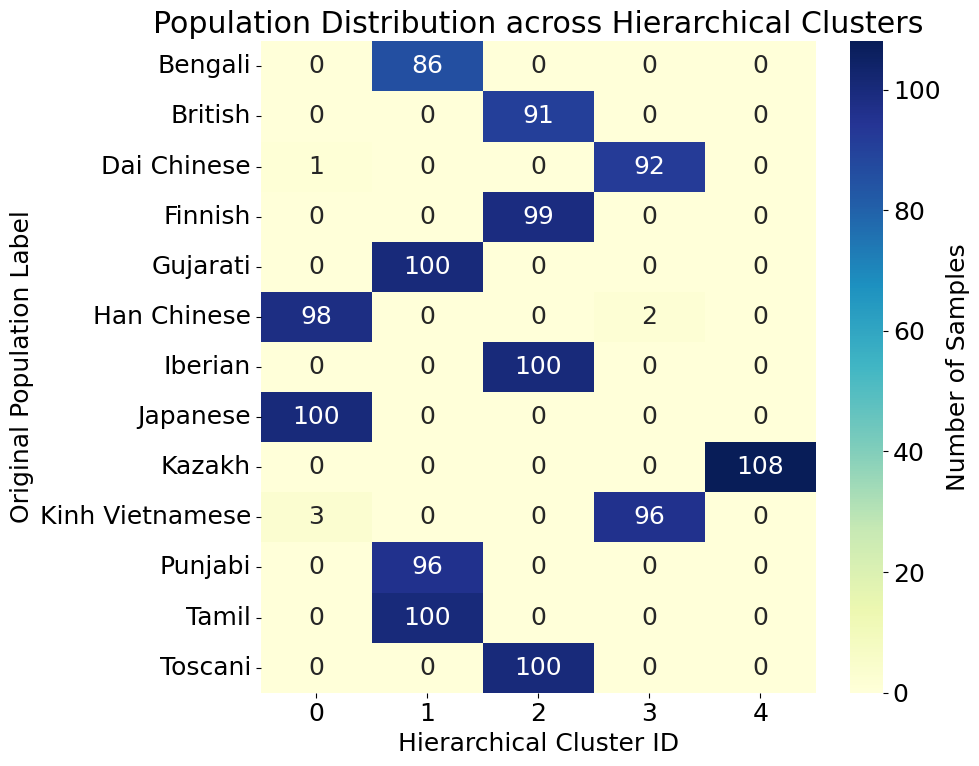

In [39]:
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
pca_data['HC_Cluster'] = hc.fit_predict(X)

import seaborn as sns

contingency_matrix = pd.crosstab(pca_data['Population'], pca_data['HC_Cluster'])

plt.figure(figsize=(10, 8))
sns.heatmap(contingency_matrix, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Number of Samples'}
)
plt.title('Population Distribution across Hierarchical Clusters')
plt.xlabel('Hierarchical Cluster ID')
plt.ylabel('Original Population Label')
plt.tight_layout()
plt.savefig("hclust_population_heatmap.pdf", format="pdf", bbox_inches="tight")
plt.show()

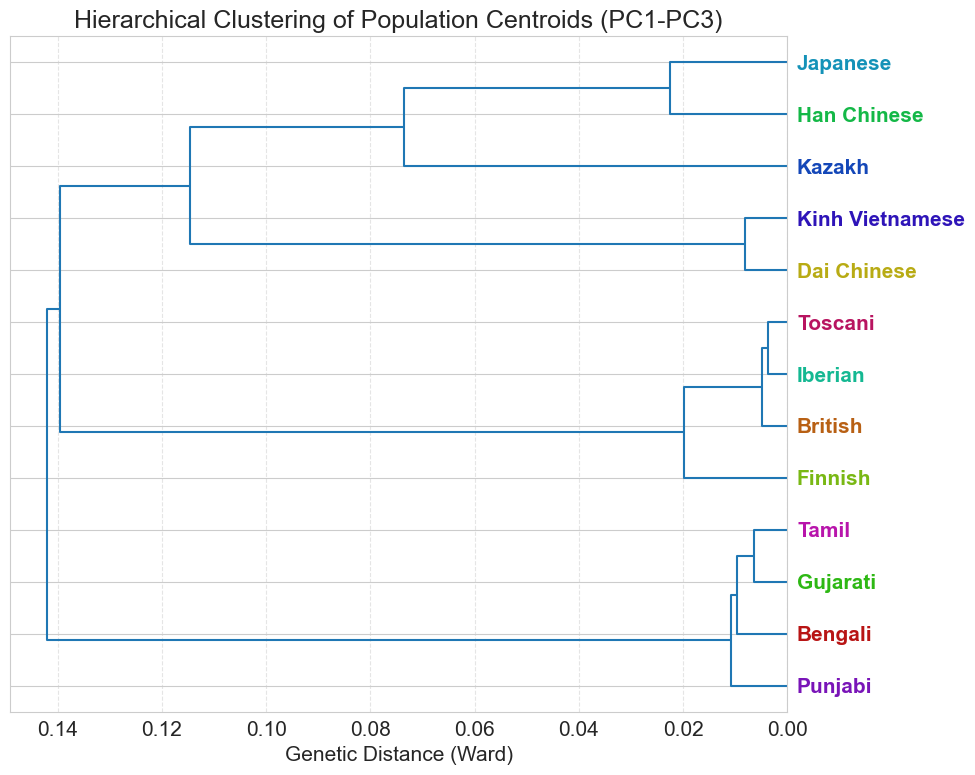

In [21]:
pop_means = pca_data.groupby('Population')[['PC1', 'PC2', 'PC3']].mean()
pop_names = pop_means.index.tolist()

Z_pop = linkage(pop_means, method='ward')

plt.figure(figsize=(10, 8))
plt.rcParams.update({'font.size': 15})

dend = dendrogram(
    Z_pop,
    labels=pop_names,
    orientation='left',
    leaf_font_size=15,
    color_threshold=0
)

ax = plt.gca()
ylbls = ax.get_ymajorticklabels()
for lbl in ylbls:
    pop_name = lbl.get_text()
    if pop_name in color_dict:
        lbl.set_color(color_dict[pop_name])
        lbl.set_weight('bold')

plt.title('Hierarchical Clustering of Population Centroids (PC1-PC3)')
plt.xlabel('Genetic Distance (Ward)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("population_dendrogram_clean_transparent.pdf", format="pdf", transparent=True, bbox_inches="tight")
plt.show()